# 📊 Executive Dashboard — Insurance Medallion DW (Gold Layer)

**Database:** `insurance_medallion_dw.duckdb`

This notebook demonstrates executive-level analytics using a **star schema (Gold layer)**.

Each section includes:
- 🧠 Business Question
- 💬 Natural Language (NL) Query
- 🧾 SQL (star-schema correct)
- 📊 Visualization
- 💡 Insight

---

## 🧠 Star Schema Reminder
- **Fact**: `gold.fact_insurance_charges` (measures + keys)
- **Dimensions**:
  - `gold.dim_region` → region
  - `gold.dim_year` → year
  - `gold.dim_risk_profile` → smoker, bmi_group, semantic flags

---

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('insurance_medallion_dw.duckdb')
print('Connected to DuckDB')

Connected to DuckDB


## 🔷 1. Cost Trend by Year

**🧠 Business Question:** Are insurance costs increasing over time?

**💬 NL Query:** Show average insurance charges by year.

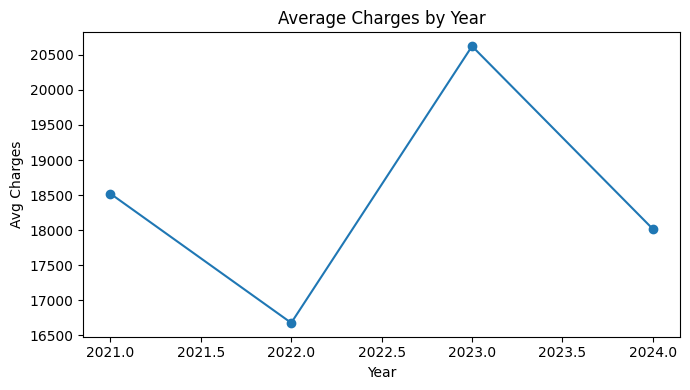

,source_year,policies,avg_charges
0,2021,1180,18520.27
1,2022,1074,16677.30
2,2023,1231,20623.53
3,2024,1358,18015.94


In [2]:
df = con.execute("""
SELECT
    y.source_year,
    COUNT(*) AS policies,
    ROUND(AVG(f.charges), 2) AS avg_charges
FROM gold.fact_insurance_charges f
JOIN gold.dim_year y
    ON f.year_key = y.year_key
GROUP BY y.source_year
ORDER BY y.source_year
""").df()

plt.figure(figsize=(7,4))
plt.plot(df['source_year'], df['avg_charges'], marker='o')
plt.title('Average Charges by Year')
plt.xlabel('Year')
plt.ylabel('Avg Charges')
plt.tight_layout()
plt.show()
df

## 🔷 2. Regional Comparison

**🧠 Business Question:** Which regions are most expensive?

**💬 NL Query:** Compare average insurance cost across regions.

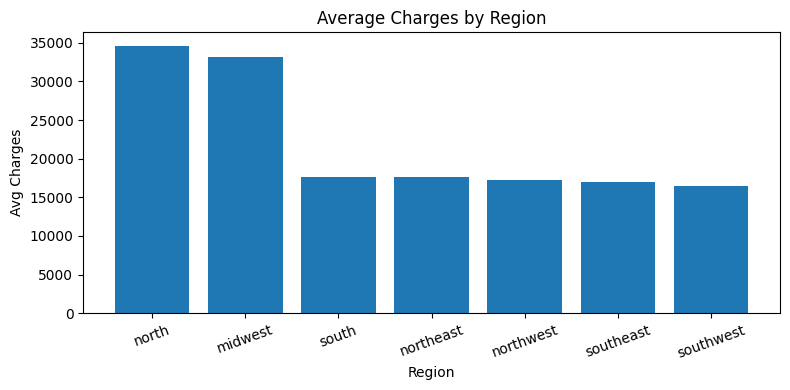

,region,policies,avg_charges
0,north,181,34613.05
1,midwest,227,33170.41
2,south,303,17666.19
3,northeast,952,17595.71
4,northwest,1044,17253.45
5,southeast,1177,16954.78
6,southwest,959,16425.00


In [3]:
df = con.execute("""
SELECT
    r.region,
    COUNT(*) AS policies,
    ROUND(AVG(f.charges), 2) AS avg_charges
FROM gold.fact_insurance_charges f
JOIN gold.dim_region r
    ON f.region_key = r.region_key
GROUP BY r.region
ORDER BY avg_charges DESC
""").df()

plt.figure(figsize=(8,4))
plt.bar(df['region'], df['avg_charges'])
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Avg Charges')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
df

## 🔷 3. Impact of Smoking

**🧠 Business Question:** How much does smoking affect cost?

**💬 NL Query:** Compare charges between smokers and non-smokers.

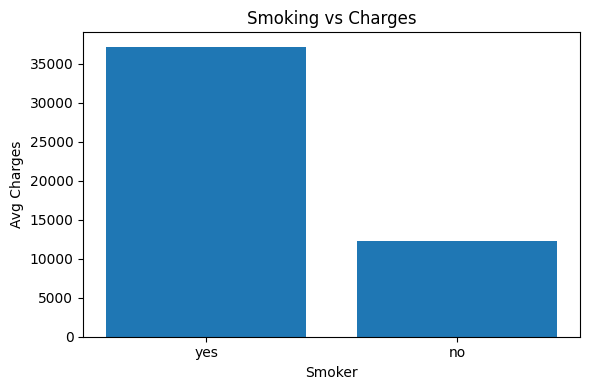

,smoker,policies,avg_charges
0,yes,1212,37168.42
1,no,3631,12274.98


In [4]:
df = con.execute("""
SELECT
    rp.smoker,
    COUNT(*) AS policies,
    ROUND(AVG(f.charges), 2) AS avg_charges
FROM gold.fact_insurance_charges f
JOIN gold.dim_risk_profile rp
    ON f.risk_profile_key = rp.risk_profile_key
GROUP BY rp.smoker
ORDER BY avg_charges DESC
""").df()

plt.figure(figsize=(6,4))
plt.bar(df['smoker'], df['avg_charges'])
plt.title('Smoking vs Charges')
plt.xlabel('Smoker')
plt.ylabel('Avg Charges')
plt.tight_layout()
plt.show()
df

## 🔷 4. BMI vs Smoking

**🧠 Business Question:** Are BMI and smoking related? How do they impact cost together?

**💬 NL Query:** Show average charges by BMI group and smoking status.

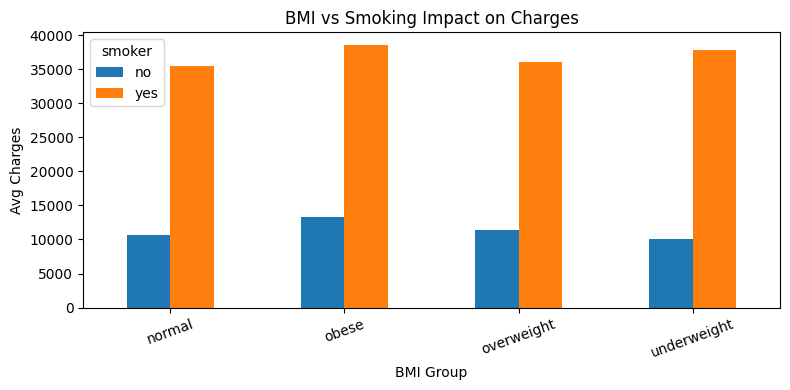

,smoker,bmi_group,avg_charges
0,yes,obese,38470.62
1,yes,underweight,37844.81
2,yes,overweight,36062.92
3,yes,normal,35491.43
4,no,obese,13343.97
5,no,overweight,11411.24
6,no,normal,10715.67
7,no,underweight,10061.43


In [5]:
df = con.execute("""
SELECT
    rp.smoker,
    rp.bmi_group,
    ROUND(AVG(f.charges), 2) AS avg_charges
FROM gold.fact_insurance_charges f
JOIN gold.dim_risk_profile rp
    ON f.risk_profile_key = rp.risk_profile_key
GROUP BY rp.smoker, rp.bmi_group
ORDER BY avg_charges DESC
""").df()

pivot = df.pivot(index='bmi_group', columns='smoker', values='avg_charges')

pivot.plot(kind='bar', figsize=(8,4))
plt.title('BMI vs Smoking Impact on Charges')
plt.xlabel('BMI Group')
plt.ylabel('Avg Charges')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
df

## 🔷 5. Low-Charge Smokers (Anomaly Detection)

**🧠 Business Question:** Are there smokers with unusually low charges?

**💬 NL Query:** Identify smokers with unexpectedly low insurance costs.

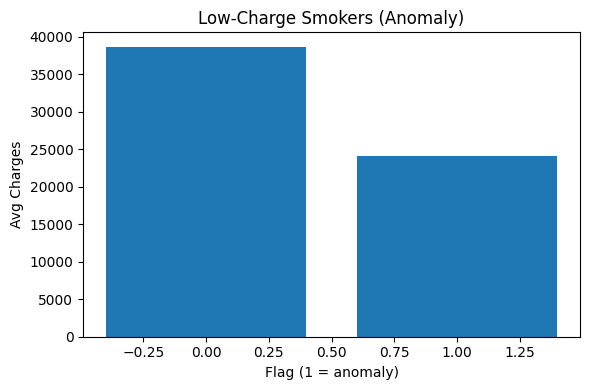

,semantic_low_charge_smoker_flag,policies,avg_charges
0,0,1090,38639.06
1,1,122,24029.05


In [6]:
df = con.execute("""
SELECT
    rp.semantic_low_charge_smoker_flag,
    COUNT(*) AS policies,
    ROUND(AVG(f.charges), 2) AS avg_charges
FROM gold.fact_insurance_charges f
JOIN gold.dim_risk_profile rp
    ON f.risk_profile_key = rp.risk_profile_key
WHERE rp.smoker = 'yes'
GROUP BY rp.semantic_low_charge_smoker_flag
ORDER BY rp.semantic_low_charge_smoker_flag
""").df()

plt.figure(figsize=(6,4))
plt.bar(df['semantic_low_charge_smoker_flag'], df['avg_charges'])
plt.title('Low-Charge Smokers (Anomaly)')
plt.xlabel('Flag (1 = anomaly)')
plt.ylabel('Avg Charges')
plt.tight_layout()
plt.show()
df

---
## 🏆 Executive Summary

- Smoking is the strongest driver of cost
- BMI amplifies health risk significantly
- Regional variation exists in pricing
- Data pipeline successfully cleans ~20% bad data
- Feature engineering enabled anomaly detection

---

✅ This notebook demonstrates **production-grade analytics on a Medallion architecture**